# Criatura Lendária - Cubo Gelatinoso

## Introdução

As criaturas lendárias são tarefas da matéria de "Aprendizado de Máquina" da Ilum - Escola de Ciência, ministrada pelo professor Dr. Daniel R. Cassar. Essas tarefas são desafios que envolvem a aplicação e desenvolvimento dos conceitos abordados em aula, devendo ser entregues em datas estabelecidas.

A primeira criatura lendária é o Cubo Gelatinoso, que envolve a busca de dados e aplicação em um algoritmo k-NN, ou, dos k-vizinhos mais próximos.

## Bibliotecas

Para organizar a realização do projeto, foram importadas as bibliotecas a seguir.

A biblioteca "statistics" será usada para fazer análise e cálculos estatísticos dos dados. A biblioteca "pandas" será usada para a manipulação e visualização dos dados. A biblioteca "numpy" teve uso em momentos de análises estatísticas. As bibliotecas "matplotlib" e "seaborn" são utilizadas para construções gráficas.

As funções importadas da biblioteca "sklearn" serão usadas para diversos fins; portanto, serão explicados nas seções em que forem utilizadas.

In [1]:
import statistics as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

from itertools import product
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    roc_curve,
)

from sklearn.inspection import permutation_importance

## Dados

Em seguida, os dados escolhidos para ser trabalhados foram do dataset "Heart Disease dataset", no qual cada linha é um paciente com indicadores clínicos e diferentes graus de doença cardíaca, indo de 0 (ausência) a 4.

Esse dataset foi encontrado no repositório UCI Machine Learning, contendo dados de Cleveland, Hungria, Suíça e VA Long Beach; porém ao baixar os dados, eles são um arquivo ZIP que contém os dados de cada local separadamente; portanto, houve o uso de IA para juntar esses dados em um único arquivo CSV.

In [2]:
dados_brutos = pd.read_csv("heart_disease_combined.csv")
dados_brutos

,source,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,cleveland,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,cleveland,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,cleveland,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,cleveland,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,cleveland,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,va_long_beach,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,NaN,NaN,NaN,1
916,va_long_beach,62.0,1.0,1.0,NaN,139.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0
917,va_long_beach,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,NaN,NaN,6.0,2
918,va_long_beach,58.0,1.0,4.0,NaN,385.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0


Logo, deve-se extrair as primeiras informações sobre o dataset, como seu tamanho e o tipo de cada objeto

In [3]:
print(f"Número de linhas: {dados_brutos.shape[0]}")
print(f"Número de colunas: {dados_brutos.shape[1]}")
print()
print(dados_brutos.dtypes)

Número de linhas: 920
Número de colunas: 15

source       object
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object


Os dados são divididos em dois grupos, os numéricos e os categóricos.

Os dados numéricos são idade (age), em anos; pressão arterial em repouso (trestbps), em mmHg; colesterol sérico (chol), em mg/dl; frequência cardíaca máxima atingida (thalach); Depressão do segmento ST induzida pelo exercício em relação ao repouso (oldpeak); e número de grandes vasos (0-3) evidenciados por fluoroscopia (ca).

Os dados categóricos são sexo (sex), onde 0 = feminino e 1 = masculino; dor no peito (cp), no qual 1 = angina típica, 2 = angina atípica, 3 = dor não-anginosa, 4 = assintomático; glicemia de jejum > 120 mg/dL (fbs), onde 0 = não e 1 = sim; ECG em repouso (restecg), 0 = normal, 1 = anormalidade da onda ST-T, 2 = hipertrofia ventricular esquerda; angina induzida pelo exercício (exang), 1 = sim e 0 = não; declive (slope), 1 = ascendente, 2 = plano, 3 = descendente; e talassemia (thal), 3 = normal, 6 = defeito fixo e 7 = defeito reversível.

O dataset ainda define o target, que é o diagnóstico da doença, sendo de 0, que representa a ausência de doença, a 4, sendo os diferentes níveis de doença.

Por fim, existe ainda a linha recurso (source), que indica o local de onde os dados foram coletados.

### Tratamento dos dados

Antes de prosseguir, foram encontrados dados faltantes no banco de dados.

In [4]:
dados_brutos.isna().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalach      55
exang        55
chol         30
restecg       2
sex           0
cp            0
source        0
age           0
num           0
dtype: int64

Nota-se que os atributos "ca", "thal" e "slope" possuem muitas linhas com dados ausentes, isso pois não foram todas as instituições que realizaram exames para adquirir esses dados. Como consequência a classificação fica imprecisa; portanto, foi decidida a retirada desses atributos e a posterior remoção de linhas com dados faltantes.

A coluna "source" não apresenta informações para o diagnóstico da doença, visto que se trata do local de origem dos dados, que não permite inferir nada para o diagnóstico de doença cardíaca.

In [5]:
dados_corrigidos = dados = dados_brutos.drop(columns=["ca", "thal", "slope", "source"])
dados_corrigidos

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
915,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,1
916,62.0,1.0,1.0,NaN,139.0,0.0,1.0,NaN,NaN,NaN,0
917,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,2
918,58.0,1.0,4.0,NaN,385.0,1.0,2.0,NaN,NaN,NaN,0


In [6]:
dados_limpos = dados_corrigidos.dropna()
dados_limpos

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
913,62.0,1.0,4.0,158.0,170.0,0.0,1.0,138.0,1.0,0.0,1
914,46.0,1.0,4.0,134.0,310.0,0.0,0.0,126.0,0.0,0.0,2
915,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,1
917,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,2


Foi possível notar que houve uma perda de 20% dos dados, mesmo retirando as colunas que havia muitos dados faltando. Em seguida, foi verificado como ficou a limpeza dos dados.

In [7]:
dados_limpos.isna().sum().sort_values(ascending=False)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
num         0
dtype: int64

Sem dados faltantes, é possível continuar o projeto com o dataset modificado.

### Análise exploratória dos dados

A seguir, foi feita a análise exploratória dos dados.

Começando com uma análise bruta dos dados, isso com o uso da função "describe", que retorna uma descrição estatística dos dados em estudo.

In [8]:
df = dados_limpos

In [9]:
df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,53.097297,0.764865,3.227027,132.754054,220.136486,0.150000,0.635135,138.744595,0.400000,0.894324,0.924324
std,9.408127,0.424370,0.939193,18.581250,93.614555,0.357313,0.840039,25.846082,0.490229,1.087160,1.128882
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-1.000000,0.000000
25%,46.000000,1.000000,2.000000,120.000000,197.000000,0.000000,0.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,231.000000,0.000000,0.000000,140.000000,0.000000,0.500000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,271.000000,0.000000,1.000000,159.250000,1.000000,1.500000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,4.000000


Em seguida, foi feita uma análise exploratória mais aprofundada de cada um dos dados, para com isso serem extraidas mais informações antes de prosseguir.

In [10]:
idade = df["age"]
print("Idade")
print(f'média: {st.mean(idade)}')
print(f'mediana: {st.median(idade)}')
print(f'moda: {st.mode(idade)}')
print(f'desvio padrão: {st.stdev(idade)}')
print(f'mínimo: {min(idade)}')
print(f'primeiro quartil: {np.percentile(idade, 25)}')
print(f'segundo quartil: {np.percentile(idade, 50)}')
print(f'terceiro quartil: {np.percentile(idade, 75)}')
print(f'máximo: {max(idade)}')
print()

sexo = df["sex"]
print("Sexo")
print(f'moda: {st.mode(sexo)}')
print(f'frações: {pd.Series(sexo).value_counts(normalize=True)}')
print()

cp = df["cp"]
print("Dor no peito")
print(f'moda: {st.mode(cp)}')
print(f'frações: {pd.Series(cp).value_counts(normalize=True)}')
print()

trestbps = df["trestbps"]
print("Pressão arterial em repouso")
print(f'média: {st.mean(trestbps)}')
print(f'mediana: {st.median(trestbps)}')
print(f'moda: {st.mode(trestbps)}')
print(f'desvio padrão: {st.stdev(trestbps)}')
print(f'mínimo: {min(trestbps)}')
print(f'primeiro quartil: {np.percentile(trestbps, 25)}')
print(f'segundo quartil: {np.percentile(trestbps, 50)}')
print(f'terceiro quartil: {np.percentile(trestbps, 75)}')
print(f'máximo: {max(trestbps)}')
print()

chol = df["chol"]
print("Colesterol sérico")
print(f'média: {st.mean(chol)}')
print(f'mediana: {st.median(chol)}')
print(f'moda: {st.mode(chol)}')
print(f'desvio padrão: {st.stdev(chol)}')
print(f'mínimo: {min(chol)}')
print(f'primeiro quartil: {np.percentile(chol, 25)}')
print(f'segundo quartil: {np.percentile(chol, 50)}')
print(f'terceiro quartil: {np.percentile(chol, 75)}')
print(f'máximo: {max(chol)}')
print()

fbs = df["fbs"]
print("Glicemia de jejum > 120 mg/dL")
print(f'moda: {st.mode(fbs)}')
print(f'frações: {pd.Series(fbs).value_counts(normalize=True)}')
print()

restecg = df["restecg"]
print("ECG em repouso")
print(f'moda: {st.mode(restecg)}')
print(f'frações: {pd.Series(restecg).value_counts(normalize=True)}')
print()

thalach = df["thalach"]
print("Frequência cardíaca máxima atingida")
print(f'média: {st.mean(thalach)}')
print(f'mediana: {st.median(thalach)}')
print(f'moda: {st.mode(thalach)}')
print(f'desvio padrão: {st.stdev(thalach)}')
print(f'mínimo: {min(thalach)}')
print(f'primeiro quartil: {np.percentile(thalach, 25)}')
print(f'segundo quartil: {np.percentile(thalach, 50)}')
print(f'terceiro quartil: {np.percentile(thalach, 75)}')
print(f'máximo: {max(thalach)}')
print()

exang = df["exang"]
print("Angina induzida pelo exercício")
print(f'moda: {st.mode(exang)}')
print(f'frações: {pd.Series(exang).value_counts(normalize=True)}')
print()

oldpeak = df["oldpeak"]
print("Depressão do segmento ST induzida pelo exercício em relação ao repouso")
print(f'média: {st.mean(oldpeak)}')
print(f'mediana: {st.median(oldpeak)}')
print(f'moda: {st.mode(oldpeak)}')
print(f'desvio padrão: {st.stdev(oldpeak)}')
print(f'mínimo: {min(oldpeak)}')
print(f'primeiro quartil: {np.percentile(oldpeak, 25)}')
print(f'segundo quartil: {np.percentile(oldpeak, 50)}')
print(f'terceiro quartil: {np.percentile(oldpeak, 75)}')
print(f'máximo: {max(oldpeak)}')
print()

Idade
média: 53.097297297297295
mediana: 54.0
moda: 54.0
desvio padrão: 9.408126694260476
mínimo: 28.0
primeiro quartil: 46.0
segundo quartil: 54.0
terceiro quartil: 60.0
máximo: 77.0

Sexo
moda: 1.0
frações: sex
1.0    0.764865
0.0    0.235135
Name: proportion, dtype: float64

Dor no peito
moda: 4.0
frações: cp
4.0    0.529730
3.0    0.217568
2.0    0.202703
1.0    0.050000
Name: proportion, dtype: float64

Pressão arterial em repouso
média: 132.75405405405405
mediana: 130.0
moda: 120.0
desvio padrão: 18.58124965528822
mínimo: 0.0
primeiro quartil: 120.0
segundo quartil: 130.0
terceiro quartil: 140.0
máximo: 200.0

Colesterol sérico
média: 220.1364864864865
mediana: 231.0
moda: 0.0
desvio padrão: 93.6145554912116
mínimo: 0.0
primeiro quartil: 197.0
segundo quartil: 231.0
terceiro quartil: 271.0
máximo: 603.0

Glicemia de jejum > 120 mg/dL
moda: 0.0
frações: fbs
0.0    0.85
1.0    0.15
Name: proportion, dtype: float64

ECG em repouso
moda: 0.0
frações: restecg
0.0    0.601351
2.0    0.

Com essa análise mais aprofundada de cada atributo é possível adquirir mais informações sobre eles. Dentre essas informações, vale ressaltar que a maioria dos pacientes são homens (mais de 76%), a idade das pessoas é concentrada na faixa de risco de doenças cardíacas (46 - 60 anos); sobre a dor no peito, a maioria são assintomáticos (4), ou seja, a maioria dos pacientes não sente dor típica no peito; dentre outras informações relacionadas às condições de saúde dos pacientes.

Abaixo, foram feitos cinco gráficos, um para cada dado numérico, mostrando a distribuição de cada um deles.

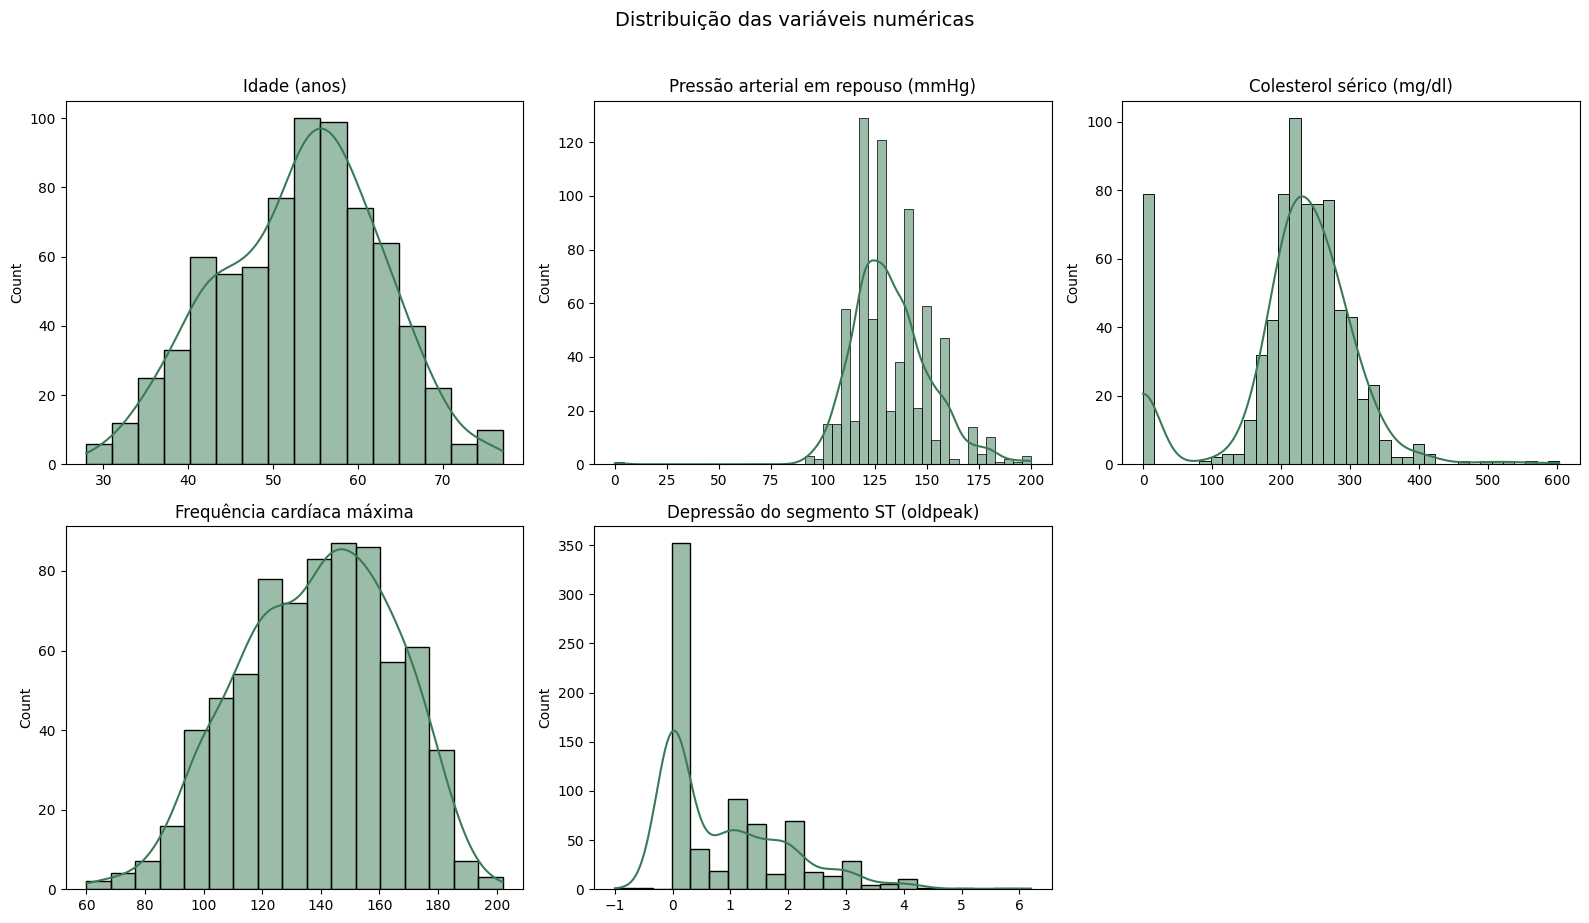

In [11]:
variaveis_numericas = ["age", "trestbps", "chol", "thalach", "oldpeak"]
nomes_pt = {
    "age": "Idade (anos)",
    "trestbps": "Pressão arterial em repouso (mmHg)",
    "chol": "Colesterol sérico (mg/dl)",
    "thalach": "Frequência cardíaca máxima",
    "oldpeak": "Depressão do segmento ST (oldpeak)",
}

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
eixos = eixos.flatten()

for i, var in enumerate(variaveis_numericas):
    sns.histplot(df[var], kde=True, ax=eixos[i], color="#3B7A57")
    eixos[i].set_title(nomes_pt[var])
    eixos[i].set_xlabel("")

eixos[-1].axis("off")
fig.suptitle("Distribuição das variáveis numéricas", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

Nota-se que a idade e a frequência cardíaca máxima dos pacientes são dados que seguem distribuições próximas a uma distribuição normal dos dados. A pressão arterial em repouso e a depressão do segmento ST são deslocados do centro e são mais distantes da distribuição normal. Por fim, o colesterol sérico segue uma distribuição próxima da normal, porém com deformidades devido a presença de outliers, tal com acontece com a presença de outliers na depressão do segmento ST.

Para avaliar a presença de outliers nos dados numéricos, foram plotados os gráficos em seguida.

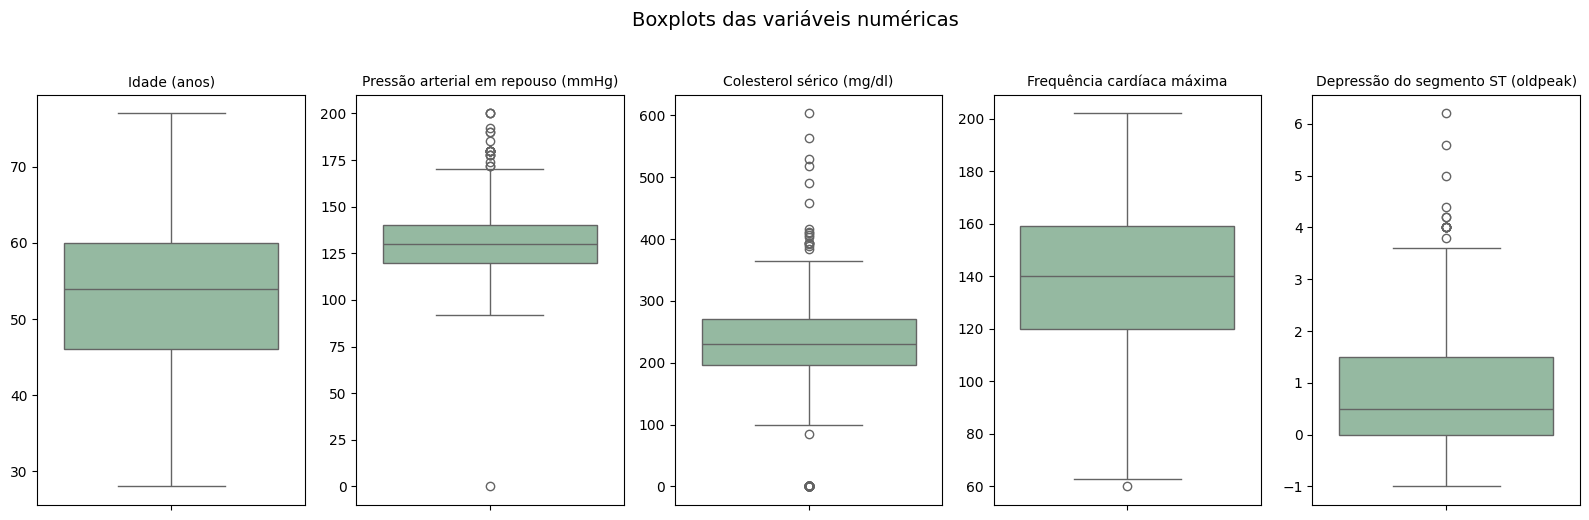

In [12]:
fig, eixos = plt.subplots(1, 5, figsize=(16, 5))

for i, var in enumerate(variaveis_numericas):
    sns.boxplot(y=df[var], ax=eixos[i], color="#8FBF9F")
    eixos[i].set_title(nomes_pt[var], fontsize=10)
    eixos[i].set_ylabel("")

fig.suptitle("Boxplots das variáveis numéricas", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

Como visto com os gráficos anteriores, a idade e a frequência cardíaca máxima são atributos muito próximos da distribuição normal, sem muitos outliers, já os outros três atributos numéricos possuem diversos outliers; porém não serão desconsiderados, pois, mesmo sendo casos mais isolados, eles ocorrem e devem ser levados em consideração.

Na terceira parte da análise gráfica, foram feitos gráficos de barra para a contagem de pacientes em cada classe dos atributos categóricos.

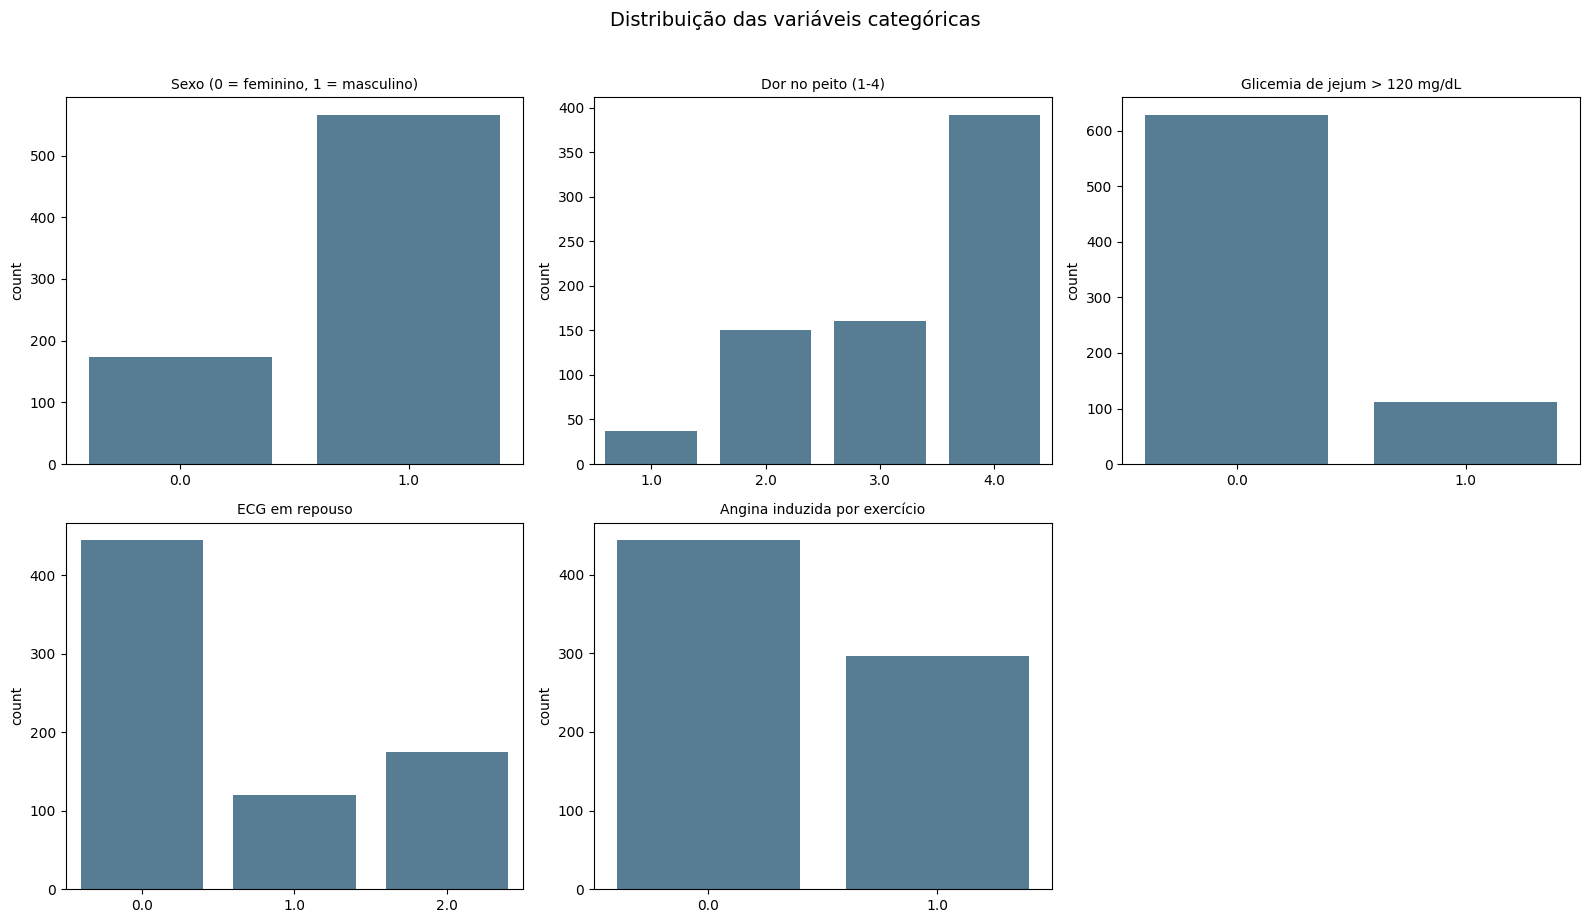

In [13]:
variaveis_categoricas = ["sex", "cp", "fbs", "restecg", "exang"]
nomes_cat_pt = {
    "sex": "Sexo (0 = feminino, 1 = masculino)",
    "cp": "Dor no peito (1-4)",
    "fbs": "Glicemia de jejum > 120 mg/dL",
    "restecg": "ECG em repouso",
    "exang": "Angina induzida por exercício",
}

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
eixos = eixos.flatten()

for i, var in enumerate(variaveis_categoricas):
    sns.countplot(x=df[var], ax=eixos[i], color="#4C7F9E")
    eixos[i].set_title(nomes_cat_pt[var], fontsize=10)
    eixos[i].set_xlabel("")

eixos[-1].axis("off")
fig.suptitle("Distribuição das variáveis categóricas", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

Os gráficos confirmam o que já havia sido observado, a maioria dos pacientes é do sexo masculino (aproximadamente 76%), a maior parte é assintomática em relação à dor no peito (4), e a maioria não apresenta glicemia de jejum elevada nem angina induzida por exercício; além de a maioria apresentar normalidade no ECG em repouso. 

### Análise do target

Em seguida, é feita uma análise exploratória dos dados da presença da doença (num), que será utilizado como target. 

In [14]:
num = df["num"]
print("Presença da doença")
print(f'moda: {st.mode(num)}')
print(f'frações: {pd.Series(num).value_counts(normalize=True)}')
print()

Presença da doença
moda: 0
frações: num
0    0.482432
1    0.275676
2    0.106757
3    0.105405
4    0.029730
Name: proportion, dtype: float64



O gráfico abaixo foi feito a fim de mostrar a distribuição do target de forma visual

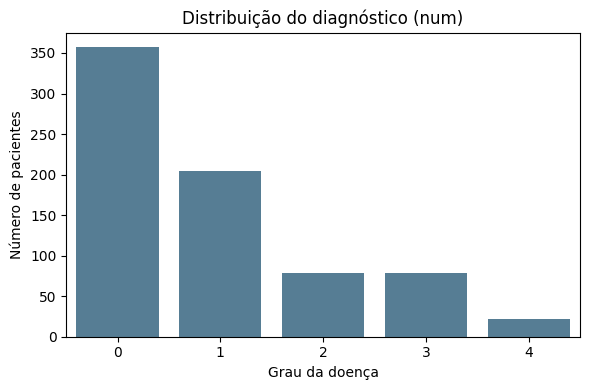

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["num"], color="#4C7F9E")
plt.title("Distribuição do diagnóstico (num)")
plt.xlabel("Grau da doença")
plt.ylabel("Número de pacientes")
plt.tight_layout()
plt.show()

Com essa análise, foi possível notar que a maioria dos pacientes foi diagnosticada sem a doença (0). Além disso, o target é categórico, mas não é binário; portanto, para a realização do projeto, o target foi transformado em binário.

### Tratamento do target

A seguir, o target é categórico ordinal, então foi tratado para que seja binário; sendo 0 = sem a doença e 1 = com a doença, essa divisão mantém uma divisão de quase 50% para cada classe do target e deixando o algoritmo menos enviesado

In [16]:
df["num"] = (df["num"] > 0).astype(int)

C:\Users\murillo2610072\AppData\Local\Temp\ipykernel_23160\441886881.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num"] = (df["num"] > 0).astype(int)


In [17]:
print(df["num"].value_counts())
print(df["num"].value_counts(normalize=True))

num
1    383
0    357
Name: count, dtype: int64
num
1    0.517568
0    0.482432
Name: proportion, dtype: float64


Agora o target para a classificação é binário e balanceado entre as duas classes.

O gráfico abaixo foi feito para apresentar de forma visual a distribuição do target depois de ser transformados para binário.

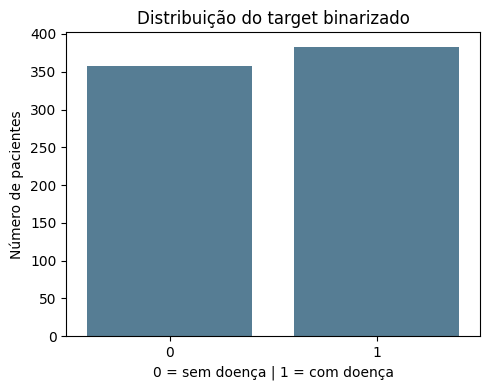

num
1    0.517568
0    0.482432
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df["num"], color="#4C7F9E")
plt.title("Distribuição do target binarizado")
plt.xlabel("0 = sem doença | 1 = com doença")
plt.ylabel("Número de pacientes")
plt.tight_layout()
plt.show()

print(df["num"].value_counts(normalize=True))

### Correlacionando os dados

Por fim, para explorar os dados, foi feito o gráfico a seguir que correlaciona os atributos entre si e com o target, permitindo a identificação de atributos com maior influência de forma visual.

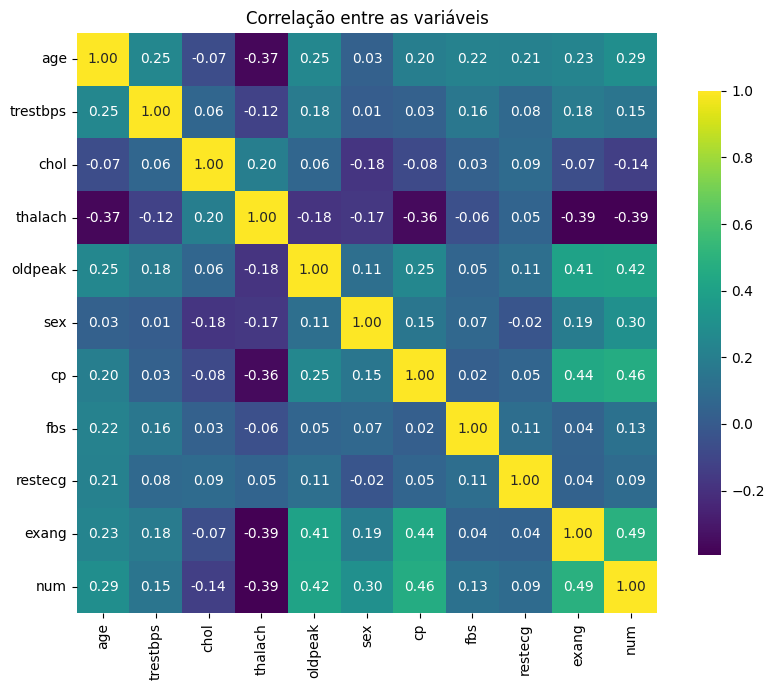

In [19]:
colunas_correlacao = variaveis_numericas + variaveis_categoricas + ["num"]
matriz_corr = df[colunas_correlacao].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="viridis", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlação entre as variáveis")
plt.tight_layout()
plt.show()

O mapa de calor expõe que "oldpeak", "cp", "exang" e "sex" são as variáveis com correlação positiva mais forte com a presença de doença cardíaca, enquanto "thalach" apresenta correlação negativa mais forte, ou seja, quanto maior a frequência cardíaca máxima atingida, menor a chance de possuir doença cardíaca.

## Definição dos atributos e do target

Em seguida, os dados foram oficialmente separados em atributos e target.

In [20]:
atributos_numericos = ["age", "trestbps", "chol", "thalach", "oldpeak"]

atributos_categoricos = ["sex", "cp", "fbs", "restecg", "exang"]

atributos = atributos_numericos + atributos_categoricos
target = "num"

## Separação dos dados de treino e teste

Para o funcionamento correto de algoritmos do tipo k_NN, foi usada a estratégia de Holdout, que consiste em separar parte dos dados para treino e outra pequena parte para testar o algoritmo, com isso o algoritmo é testado sem vazamento de dados. Para essa estratégia, os dados foram separados em dois grupos: grupo de treino, com 80% dos dados, e grupo de teste, que contém os outros 20% dos dados do dataset. Essa separação foi realizada pelo objeto "train_test_split".

Também foi definida uma semente aleatória para garantir a reprodutibilidade dos resultados. Além disso, objeto "stratify" foi usado para estratificar os dados, fazendo com que os dados de treino e teste mantenham as mesmas proporções de pacientes com e sem a doença

In [21]:
X = df[atributos]
y = df[target]

X_treino, X_teste, Y_treino, Y_teste = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 8888,
    stratify=y,
)

In [22]:
print(f'Dados para treino:{Y_treino.count()}')
print("Proporção no treino:")
print(Y_treino.value_counts(normalize=True))
print()

print(f'Dados para teste:{Y_teste.count()}')
print("Proporção no teste:")
print(Y_teste.value_counts(normalize=True))

Dados para treino:592
Proporção no treino:
num
1    0.516892
0    0.483108
Name: proportion, dtype: float64

Dados para teste:148
Proporção no teste:
num
1    0.52027
0    0.47973
Name: proportion, dtype: float64


Com isso, os dados de treino e teste foram separados; é possível notar que a estratificação ocorreu de forma correta, pois as proporções de pacientes com e sem a doença nos dados de treino e teste estão similares.

## Normalizando os atributos

Após a divisão, os atributos foram normalizados utilizando o objeto "StandardScaler", isso foi necessário pois os algoritmos k-NN são sensíveis à escala dos atributos, uma vez que depende da distância do objeto aos atributos; sem normalização, os atributos com valores maiores dominam a classificação, e dados categóricos, que são interpretados de forma binária, acabam perdendo influência.

In [23]:
normalizador = StandardScaler()
normalizador.fit(X_treino)

X_treino = pd.DataFrame(normalizador.transform(X_treino), columns=atributos, index=X_treino.index)
X_teste = pd.DataFrame(normalizador.transform(X_teste), columns=atributos, index=X_teste.index)

X_treino

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang
399,-0.575911,0.938578,0.078791,-0.337612,0.108607,-1.831104,0.829278,-0.403813,-0.755279,1.236897
819,1.060074,-0.143377,-2.327626,0.843864,1.956171,0.546119,-0.235652,2.476395,0.443448,-0.808475
841,2.259797,0.938578,0.407421,-0.337612,2.879953,0.546119,0.829278,2.476395,0.443448,1.236897
88,-0.030583,0.289405,0.152998,0.843864,-0.815175,-1.831104,0.829278,-0.403813,1.642175,-0.808475
730,0.296614,-0.359768,-0.567868,0.056213,-0.815175,0.546119,-1.300581,-0.403813,0.443448,-0.808475
...,...,...,...,...,...,...,...,...,...,...
595,0.514746,2.561511,1.838550,-1.125263,0.108607,-1.831104,-1.300581,-0.403813,-0.755279,1.236897
709,1.387271,0.938578,-2.327626,-1.204028,1.032389,0.546119,0.829278,-0.403813,-0.755279,1.236897
446,0.078483,-0.143377,0.354416,0.646952,-0.815175,-1.831104,-1.300581,-0.403813,0.443448,-0.808475
317,-1.993765,-0.684355,0.937468,1.631515,-0.815175,0.546119,-1.300581,-0.403813,1.642175,-0.808475


Com os dados na mesma escala, os dados estão finalmente prontos para serem usados no algoritmo.

## Modelo Baseline

Antes de prosseguir para o algoritmo k-NN, foi criado um modelo Baseline para que seja usado de referência e para análises comparativas. Esse modelo prevê sempre a classe mais frequente do target, não possuindo grande desempenho.

### Instanciando e treinando o Baseline

O modelo Baseline deve ser instanciado e treinado, para que em seguida possa realizar as classificações. Esse modelo foi feito pelo objeto "DummyClassifier".

In [24]:
modelo_baseline = DummyClassifier(strategy="prior", random_state=8888)
modelo_baseline.fit(X_treino, Y_treino)

,strategy,'prior'
,random_state,8888
,constant,None


### Previsão do Baseline

Em seguida, o Baseline usa os dados dos atributos de teste para realizar sua previsão e com isso é possível realizar uma comparação com os dados do target de teste e verificar seu desempenho.

In [25]:
Y_previsao_baseline = modelo_baseline.predict(X_teste)
print(Y_previsao_baseline)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Para a avaliação do modelo Baseline, foi feita uma matriz de confusão de seu desempenho.

[Text(0, 0.5, 'Sem doença'), Text(0, 1.5, 'Com doença')]

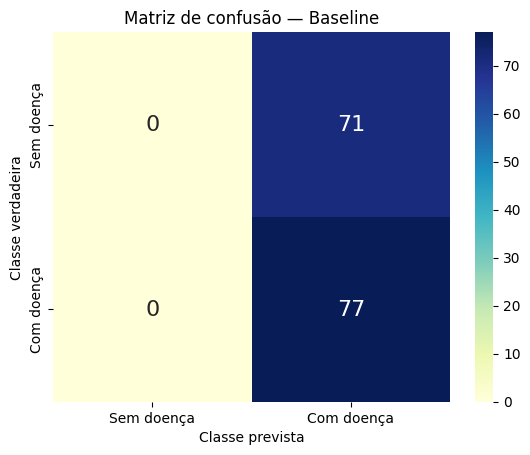

In [26]:
ordem_labels = [0, 1]
nomes_classes = ["Sem doença", "Com doença"]

matriz_confusao_baseline = confusion_matrix(Y_teste, Y_previsao_baseline, labels=ordem_labels)
df_confusao_baseline = pd.DataFrame(matriz_confusao_baseline, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_confusao_baseline, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — Baseline")
eixo.set_xticklabels(nomes_classes)
eixo.set_yticklabels(nomes_classes)

Para avaliar o desempenho, a métrica utilizada foi a acurácia. Mas, visto que os dados são desbalanceados, também foi utilizado o F1-score, pois o Baseline é enviesado para a classe com mais atributos e o F1-score mede o desempenho com base na média harmônica entre precisão e recall, levando em conta as classes minoritárias. A acurácia e o F1-score são calculados pelos objetos "accuracy_score" e "f1_score", respectivamente.

In [27]:
acuracia_baseline = accuracy_score(Y_teste, Y_previsao_baseline)
f1_baseline = f1_score(Y_teste, Y_previsao_baseline)

print(f"Acurácia = {(acuracia_baseline*100):.2f}%")
print(f"F1-score = {(f1_baseline*100):.2f}%")

Acurácia = 52.03%
F1-score = 68.44%


Nota-se que o modelo Baseline teve um desempenho médio para a resolução do problema. Aqui o F1-score acabou sendo curioso, pois está maior que a acurácia, evento que geralmente não acontece; isso ocorre pois o recall foi artificialmente inflado para 1, uma vez que o modelo só preve os positivos, consequentemente nunca errando-os. 

## Algoritmo k-NN

A seguir, o algoritmo de modelo k-vizinhos mais próximos será implementado efetivamente.

### Instanciando e treinando o k-NN inicial

O modelo k-NN deve ser instanciado e treinado, para que em seguida possa realizar as classificações. O modelo é criado com o objeto "KNeighborsClassifier".

In [28]:
modelo_knn = KNeighborsClassifier(n_neighbors = 9)

modelo_knn.fit(X_treino, Y_treino)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Previsão inicial do k-NN

O k-NN realiza previsões com os treinos de teste, essas previsões podem ser comparadas com o target de teste. Com isso pode-se analisar o desempenho do modelo k-NN, que neste caso é um modelo inicial onde foi optado pelo uso do número de vizinhos igual a 9 e os hiperparâmetros padrões da biblioteca "sklearn"

In [29]:
Y_previsao_knn = modelo_knn.predict(X_teste)
print(Y_previsao_knn)

[1 1 0 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0
 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0
 1 0 1 0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 0 1 1
 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0]


Foi então feita outra matriz de confusão, para analisar o desempenho do modelo k-NN inicial. Além da matriz de confusão, foram usadas a acurácia e F1-score como métricas de desempenho para a análise.

[Text(0, 0.5, 'Sem doença'), Text(0, 1.5, 'Com doença')]

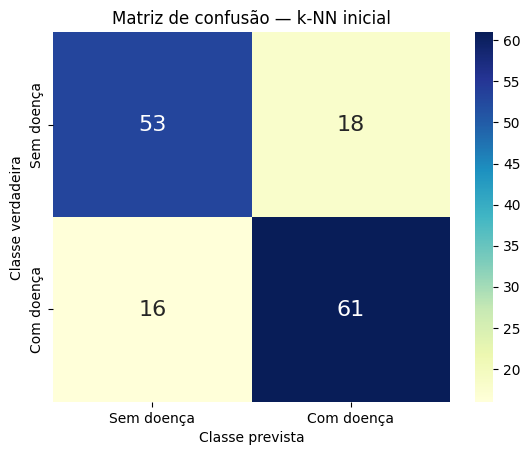

In [30]:
Y_verdadeiro = Y_teste
Y_previsao = modelo_knn.predict(X_teste)

matriz_confusao = confusion_matrix(Y_verdadeiro, Y_previsao, labels=ordem_labels)
df_confusao = pd.DataFrame(matriz_confusao, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_confusao, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — k-NN inicial")
eixo.set_xticklabels(nomes_classes)
eixo.set_yticklabels(nomes_classes)

In [31]:
acuracia = accuracy_score(Y_verdadeiro, Y_previsao)
f1 = f1_score(Y_verdadeiro, Y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")
print(f"F1-score = {f1*100:.2f}%")

Acurácia = 77.03%
F1-score = 78.21%


É possível com esses dados do desempenho verificar que o modelo k-NN é notavelmente melhor que o baseline, mesmo que ainda haja alguns erros; fato que era esperado, pois este se baseia na distância entre os dados.

### Verificação da importância de cada atributo no modelo inicial

Para verificar a importância de cada um dos atributos para a construção do algoritmo k-NN implementado, os atributos foram permutados 50 vezes cada, com o uso do objeto "permutation_importance", avaliando como essa permutação afeta o F1-score do modelo. Se o embaralhamento piorar essa métrica de desempenho, isso significa que o atributo era importante para o modelo; caso contrário, se trata de um atributo de pouca importância.

In [32]:
resultado_importancia = permutation_importance(
    modelo_knn,
    X_teste,
    Y_teste,
    n_repeats=50,
    random_state=8888,
    scoring="f1",
)

importancia = resultado_importancia.importances_mean

Para a visualização da importância de cada atributo para o algoritmo k-NN, foi feito o gráfico a seguir.

C:\Users\murillo2610072\AppData\Local\Temp\ipykernel_23160\520180733.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eixo.set_xticklabels(eixo.get_xticklabels(), rotation=45, ha="right");


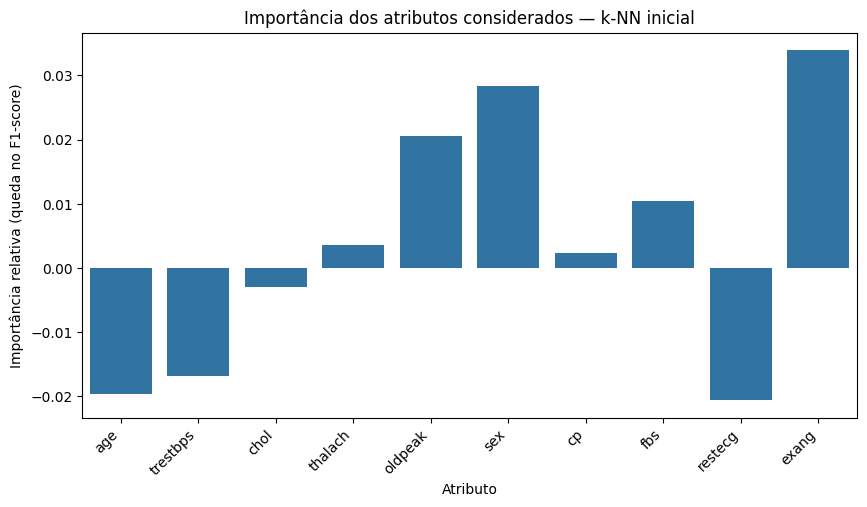

In [33]:
plt.figure(figsize=(10, 5))
eixo = sns.barplot(x=atributos, y=importancia)
eixo.set_ylabel("Importância relativa (queda no F1-score)")
eixo.set_xlabel("Atributo")
eixo.set_title("Importância dos atributos considerados — k-NN inicial")
eixo.set_xticklabels(eixo.get_xticklabels(), rotation=45, ha="right");

É possível concluir com a análise do gráfico que "oldpeak", "sex" e "exang" são atributos de alta relevância para a classificação pelo modelo k-NN desenvolvido, além de "fbs" apresentar importância moderada.

### Testando diferentes conjuntos de hiperparâmetros

Os hiperparâmetros são variáveis de configuração externa que são definidos manualmente, eles influenciam diretamente o desempenho e precisão do algoritmo. Para desenvolver o classificador k-NN com melhores desempenhos, podemos buscar conjuntos distintos de hiperparâmetros que geram um percentual de acerto melhor.

Os hiperparâmetros para algoritmos k-NN que foram variados para teste foram o número de vizinhos, os pesos e as métricas de distância utilizados.

In [34]:
k_vizinhos = [1, 5, 9, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, 201, 301, 401, 501, 591]
pesos = ["uniform", "distance"]
distancias = ["euclidean", "manhattan", "chebyshev"]

O número de vizinhos foi variado entre os extremos, 1 vizinho e todos os vizinhos, com 18 números diferentes de vizinhos, sendo apenas quantidades ímpares escolhidas para que não houvesse empates. Já os pesos foram o uniforme, onde todos os vizinhos tem a mesma relevância (padrão do algoritmo do "sklearn"), e o peso da distância, onde vizinhos mais próximos pesam mais na classificação. Por último, as métricas de distância usadas foram três: euclidiana (padrão do algoritmo do "sklearn"), manhattan e chebyshev. O resultado foi 108 combinações diferentes de hiperparâmetros.

Em seguida, foram analisados os diferentes conjuntos de hiperparâmetros para o algoritmo.

In [35]:
resultados_hiperparametros = []

for metrica in distancias:
    
    modelo = KNeighborsClassifier(metric = metrica, n_jobs = -1)
    modelo.fit(X_treino, Y_treino)

    for k, peso in product(k_vizinhos, pesos):
        modelo.set_params(n_neighbors = k, weights = peso)

        Y_previsao = modelo.predict(X_teste)
        acuracia = accuracy_score(Y_teste, Y_previsao)
        f1 = f1_score(Y_teste, Y_previsao)

        resultados_hiperparametros.append({
            "n_neighbors": k,
            "weights": peso,
            "metric": metrica,
            "acuracia": acuracia,
            "f1_score": f1,
        })

In [36]:
print(f"Número de conjuntos de hiperparâmetros avaliados: {len(resultados_hiperparametros)}")

Número de conjuntos de hiperparâmetros avaliados: 108


Foram feitos 108 conjuntos de hiperparâmetros. Abaixo está o dataframe dos diferentes conjuntos de hiperparâmetros ordenados pela acurácia e pelo F1-score.

In [37]:
df_hiperparametros = pd.DataFrame(resultados_hiperparametros)

In [38]:
print("Pela Acurácia:")
df_hiperparametros = df_hiperparametros.sort_values(by="acuracia", ascending=False)
df_hiperparametros.head(10)

Pela Acurácia:


,n_neighbors,weights,metric,acuracia,f1_score
46,31,uniform,manhattan,0.844595,0.847682
11,31,distance,euclidean,0.831081,0.836601
47,31,distance,manhattan,0.831081,0.834437
50,51,uniform,manhattan,0.831081,0.834437
51,51,distance,manhattan,0.831081,0.834437
71,591,distance,manhattan,0.831081,0.836601
49,41,distance,manhattan,0.824324,0.831169
68,501,uniform,manhattan,0.824324,0.821918
42,11,uniform,manhattan,0.824324,0.833333
10,31,uniform,euclidean,0.824324,0.828947


In [39]:
print("Pelo F1-score:")
df_hiperparametros = df_hiperparametros.sort_values(by="f1_score", ascending=False)
df_hiperparametros.head(10)

Pelo F1-score:


,n_neighbors,weights,metric,acuracia,f1_score
46,31,uniform,manhattan,0.844595,0.847682
11,31,distance,euclidean,0.831081,0.836601
71,591,distance,manhattan,0.831081,0.836601
47,31,distance,manhattan,0.831081,0.834437
50,51,uniform,manhattan,0.831081,0.834437
51,51,distance,manhattan,0.831081,0.834437
43,11,distance,manhattan,0.824324,0.833333
42,11,uniform,manhattan,0.824324,0.833333
49,41,distance,manhattan,0.824324,0.831169
10,31,uniform,euclidean,0.824324,0.828947


É possível notar que, tanto pela acurácia, quanto pelo F1-score, a combinação de 31 vizinhos, peso uniforme e distância manhattan foram a melhor combinação.

Para análise mais geral, foram feitos os gráficos a seguir.

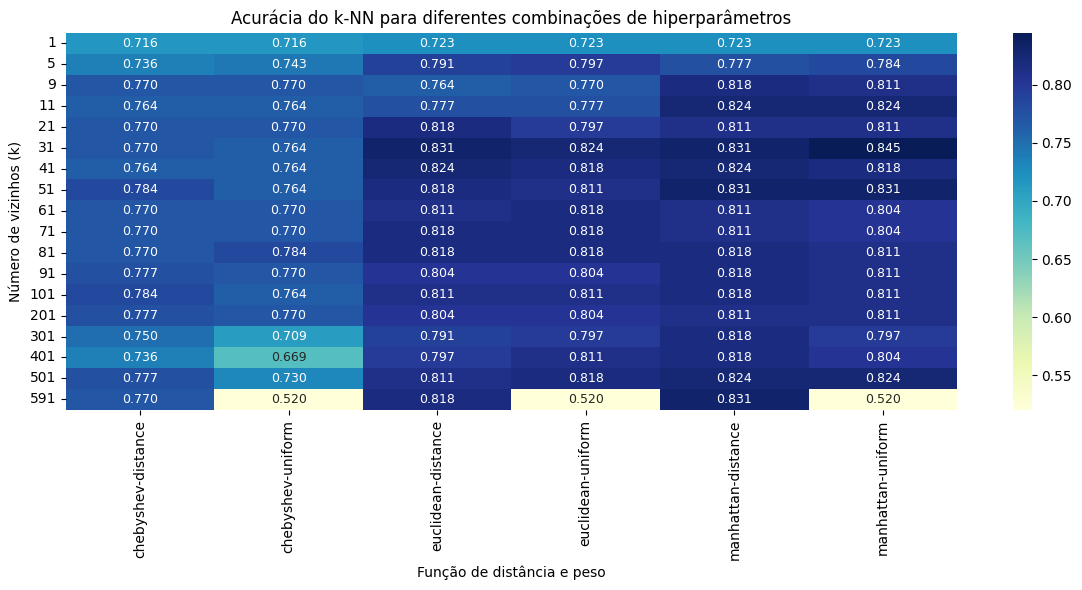

In [40]:
tabela_acuracia = df_hiperparametros.pivot_table(
    index="n_neighbors",
    columns=["metric", "weights"],
    values="acuracia",
)

plt.figure(figsize=(12, 6))
sns.heatmap(tabela_acuracia, annot=True, annot_kws={"size": 9}, fmt=".3f", cmap="YlGnBu")
plt.xlabel("Função de distância e peso")
plt.ylabel("Número de vizinhos (k)")
plt.title("Acurácia do k-NN para diferentes combinações de hiperparâmetros")
plt.tight_layout()

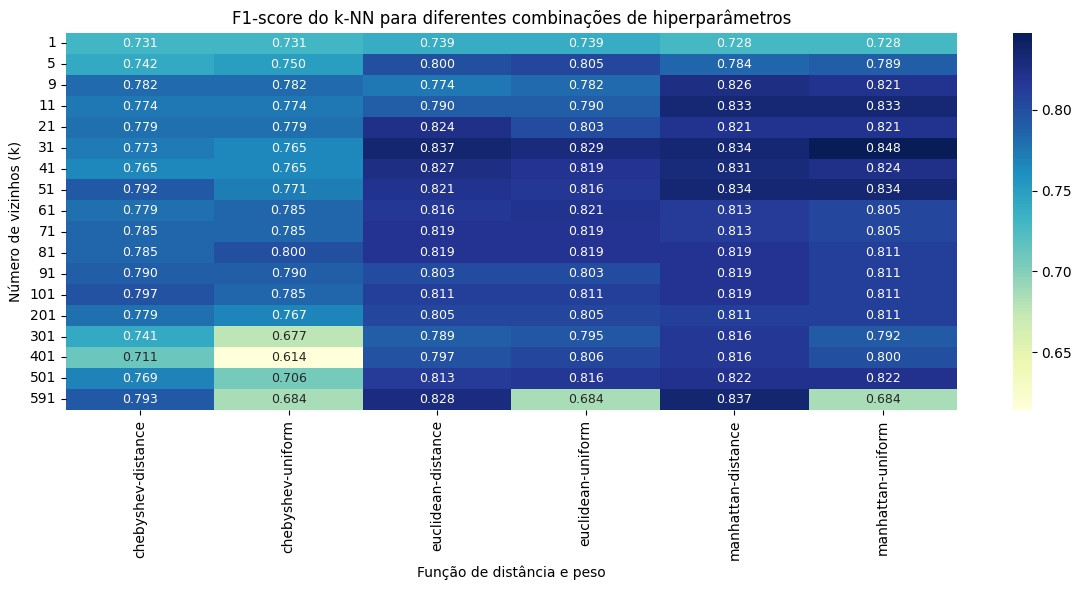

In [41]:
tabela_f1 = df_hiperparametros.pivot_table(
    index="n_neighbors",
    columns=["metric", "weights"],
    values="f1_score",
)

plt.figure(figsize=(12, 6))
sns.heatmap(tabela_f1, annot=True, annot_kws={"size": 9}, fmt=".3f", cmap="YlGnBu")
plt.xlabel("Função de distância e peso")
plt.ylabel("Número de vizinhos (k)")
plt.title("F1-score do k-NN para diferentes combinações de hiperparâmetros")
plt.tight_layout()

Com os gráficos acima, é possível perceber que números de vizinhos médios e altos, com as distâncias euclidiana e manhattan, apresentam de forma consistente resultados melhores; sendo o peso de distância geralmente melhor. Porém, reafirmando, tanto pela acurácia, quanto pelo F1-score, a combinação de 31 vizinhos mais próximos, peso uniforme e distância manhattan foram a melhor combinação; com acurácia de 0.845 e F1-score de 0.848.

É possível perceber que o número de vizinhos altera significativamente a acurácia e o F1-score, por isso, foram feitos os gráficos a seguir, que apresentam a variação da acurácia e do F1-score em função da variação do número de vizinhos para os diferentes pesos e distâncias, complementando a visão do gráfico anterior. 

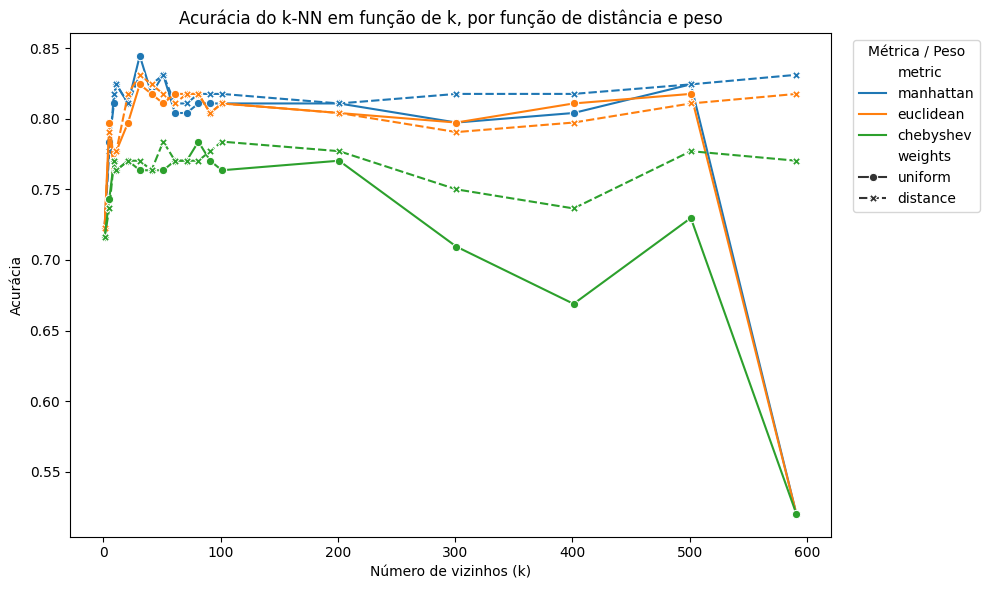

In [42]:
plt.figure(figsize=(10, 6))

eixo = sns.lineplot(
    data=df_hiperparametros,
    x="n_neighbors",
    y="acuracia",
    hue="metric",
    style="weights",
    markers=True,
    dashes=True,
)

eixo.set_xlabel("Número de vizinhos (k)")
eixo.set_ylabel("Acurácia")
eixo.set_title("Acurácia do k-NN em função de k, por função de distância e peso")
eixo.legend(title="Métrica / Peso", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

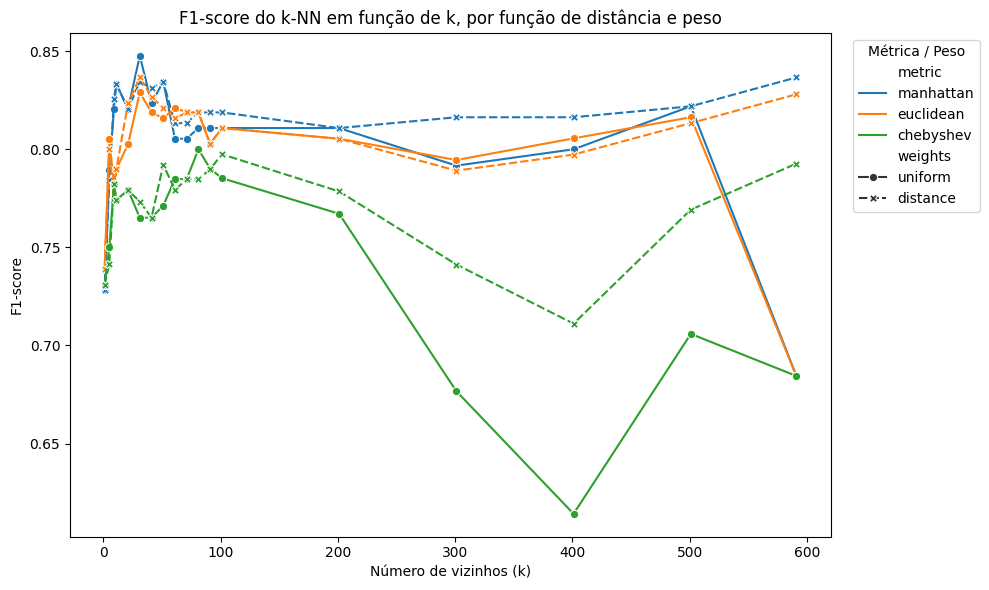

In [43]:
plt.figure(figsize=(10, 6))

eixo = sns.lineplot(
    data=df_hiperparametros,
    x="n_neighbors",
    y="f1_score",
    hue="metric",
    style="weights",
    markers=True,
    dashes=True,
)

eixo.set_xlabel("Número de vizinhos (k)")
eixo.set_ylabel("F1-score")
eixo.set_title("F1-score do k-NN em função de k, por função de distância e peso")
eixo.legend(title="Métrica / Peso", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Assim, fica ainda mais clara a influência dos hiperparâmetros sobre o desempenho do modelo.

### Versão final do k-NN

A versão final do algoritmo k-NN desenvolvido é a com os hiperparâmetros que levaram ao melhor desempenho do modelo de classificação. 

Primeiro, foi separado o conjunto de hiperparâmetros com melhor F1-score, que também possui a melhor acurácia.

In [44]:
melhor_f1 = df_hiperparametros.loc[df_hiperparametros["f1_score"].idxmax()]
print("Conjunto de hiperparâmetros com melhor F1-score:")
print(melhor_f1)

Conjunto de hiperparâmetros com melhor F1-score:
n_neighbors           31
weights          uniform
metric         manhattan
acuracia        0.844595
f1_score        0.847682
Name: 46, dtype: object


Em seguida o modelo é instanciado e treinado com o melhor conjunto de hiperparâmetros.

In [45]:
melhor_k = int(melhor_f1["n_neighbors"])
melhor_peso = melhor_f1["weights"]
melhor_metrica = melhor_f1["metric"]

modelo_knn_final = KNeighborsClassifier(
    n_neighbors=melhor_k,
    weights=melhor_peso,
    metric=melhor_metrica,
)
modelo_knn_final.fit(X_treino, Y_treino)

,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


Para verificar o desempenho do modelo final, foi feita uma matriz de confusão do modelo, além dos valores da acurácia e do F1-score.

[Text(0, 0.5, 'Sem doença'), Text(0, 1.5, 'Com doença')]

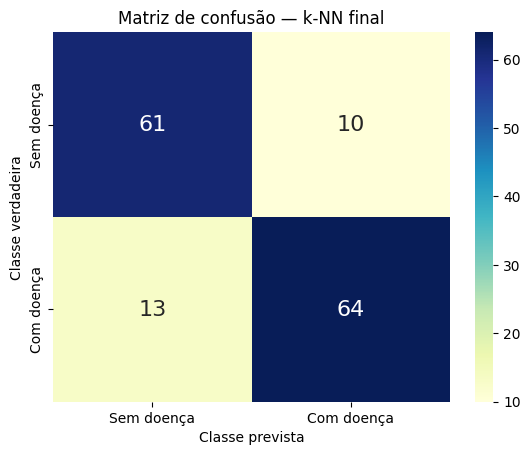

In [46]:
Y_previsao_final = modelo_knn_final.predict(X_teste)

matriz_confusao_final = confusion_matrix(Y_teste, Y_previsao_final, labels=ordem_labels)
df_confusao_final = pd.DataFrame(matriz_confusao_final, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_confusao_final, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — k-NN final")
eixo.set_xticklabels(nomes_classes)
eixo.set_yticklabels(nomes_classes)

In [47]:
acuracia_final = accuracy_score(Y_teste, Y_previsao_final)
f1_final = f1_score(Y_teste, Y_previsao_final)

print(f"Acurácia = {(acuracia_final*100):.2f}%")
print(f"F1-score = {(f1_final*100):.2f}%")

Acurácia = 84.46%
F1-score = 84.77%


Ao comparar o modelo final k-NN com o primeiro modelo k-NN desenvolvido nesse projeto, é possível notar uma melhora significativa tanto na acurácia, quanto no F1-score, reduzindo portanto o número de resultados falsos negativos e positivos.

Além disso, foi comparado o F1-score do modelo k-NN final aplicado aos dados de treino e de teste, com o intuito de verificar se o modelo não está sofrendo de overfitting.

In [48]:
f1_treino_final = f1_score(Y_treino, modelo_knn_final.predict(X_treino))
f1_teste_final = f1_score(Y_teste, modelo_knn_final.predict(X_teste))

print(f"F1-score no treino: {f1_treino_final:.3f}")
print(f"F1-score no teste: {f1_teste_final:.3f}")
print(f"F1 no treino - F1 no teste = {f1_treino_final - f1_teste_final:.3f}")

F1-score no treino: 0.803
F1-score no teste: 0.848
F1 no treino - F1 no teste = -0.045


O resultado da diferença entre o F1-score no treino e do F1-score no teste foi negativa, sendo -0.045, isso mostra que não há overfitting, que apresentaria como resultado da diferença um valor alto e positivo. Isso mostra que o modelo está generalizando bem e, por consequência, fazendo boas classificações.

### Verificação da importância de cada atributo no modelo final

Com o melhor conjunto de hiperparâmetros, o modelo final possui o melhor desempenho. Por fim, é interessante saber quais são os atributos que mais contribuem para o modelo final. Essa análise foi feita da mesma maneira que para o modelo k-NN inicial.

In [49]:
resultado_importancia_final = permutation_importance(
    modelo_knn_final,
    X_teste,
    Y_teste,
    n_repeats=50,
    random_state=8888,
    scoring="f1",
)

importancia_final = resultado_importancia_final.importances_mean

Então, foi gerado um gráfico para a visualização da importância de cada atributo.

C:\Users\murillo2610072\AppData\Local\Temp\ipykernel_23160\1888675897.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eixo.set_xticklabels(eixo.get_xticklabels(), rotation=45, ha="right");


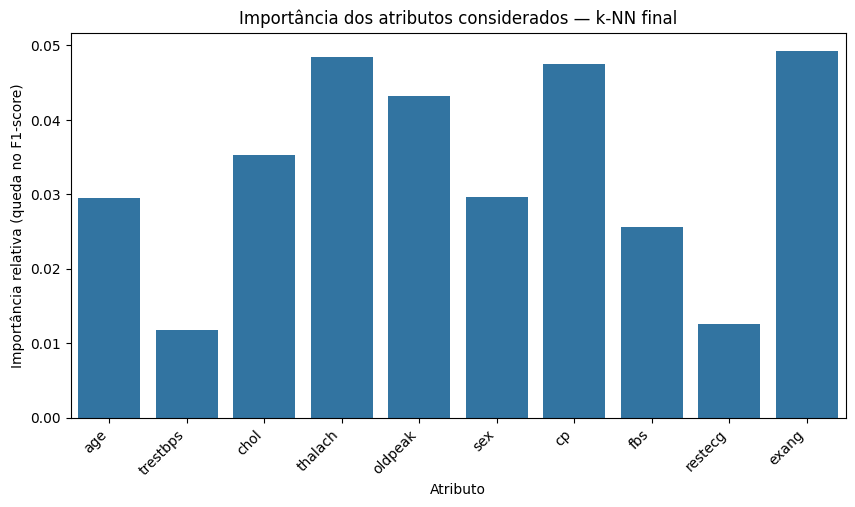

In [50]:
plt.figure(figsize=(10, 5))
eixo = sns.barplot(x=atributos, y=importancia_final)
eixo.set_ylabel("Importância relativa (queda no F1-score)")
eixo.set_xlabel("Atributo")
eixo.set_title("Importância dos atributos considerados — k-NN final")
eixo.set_xticklabels(eixo.get_xticklabels(), rotation=45, ha="right");

É possível notar, que no modelo final, todos os atributos agora exercem relevância para a classificação. Os atributos que já exerciam alta e média influência se mantiveram, porém outros atributos ganharam alta e média influência também, dado interessante.

## Comparando os modelos

Para fins avaliativos, o modelo k-NN final foi comparado ao modelo Baseline desenvolvido anteriormente. A seguir, é apresentada a curva ROC dos dois modelos comparados, feita com base nos resultados dos objetos "roc_auc_score" e "roc_curve", que permite uma interpretação visual da capacidade de cada um de diferenciar as classes considerando diferentes fronteiras de decisão.

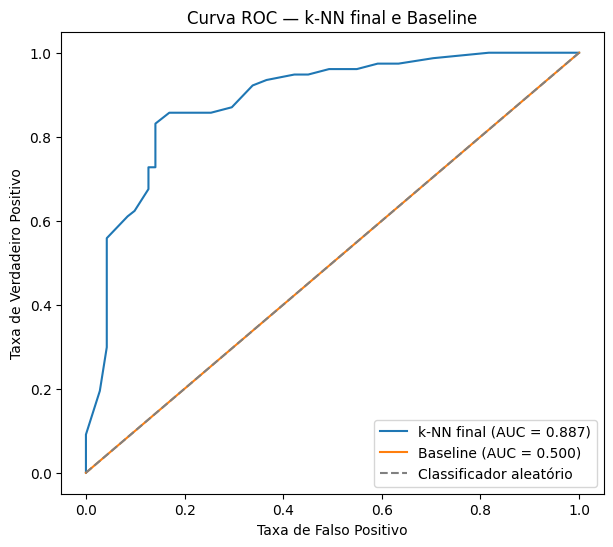

In [51]:
auc_knn = roc_auc_score(Y_teste, modelo_knn_final.predict_proba(X_teste)[:, 1])
auc_baseline = roc_auc_score(Y_teste, modelo_baseline.predict_proba(X_teste)[:, 1])

fpr_knn, tpr_knn, _ = roc_curve(Y_teste, modelo_knn_final.predict_proba(X_teste)[:, 1])
fpr_base, tpr_base, _ = roc_curve(Y_teste, modelo_baseline.predict_proba(X_teste)[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, label=f'k-NN final (AUC = {auc_knn:.3f})')
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {auc_baseline:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.title("Curva ROC — k-NN final e Baseline")
plt.legend();

Essa curva mostra claramente o melhor desempenho do modelo k-NN desenvolvido em comparação ao Baseline. Isso é exposto pelo fato de a curva do Baseline ficar exatamente na diagonal do gráfico, que corresponde a um classificador aleatório; já a curva do modelo k-NN final se aproxima do canto superior esquerdo, mostrando sua capacidade de classificar pacientes com ou sem doença cardíaca de maneira melhor que o baseline

## Conclusões e principais aprendizados

O notebook desenvolvido para esta atividade permitiu a verificação de como o algoritmo k-NN é influenciado por diferentes condições, como a quantidade de vizinhos, o peso atribuído a cada vizinho conforme sua proximidade à observação avaliada e a função de distância escolhida.

Em um primeiro momento, foram desenvolvidos aprendizados conforme a necessidade de tratamento dos dados antes de treinar qualquer modelo. O conjunto de dados combinado pode apresentar dados faltantes; incluí-los diretamente introduziria um viés relevante nas análises, motivo pelo qual optou-se por removê-los, ainda restando um número de atributos muito superior ao mínimo exigido pela atividade. Além disso, ao tratar os dados, deve-se ter cuidado para normalizar os atributos, pois é essencial para um algoritmo baseado em distância como o k-NN.

Ao variar os hiperparâmetros do modelo, foi possível observar que a distância de manhattan apresentou, de forma consistente, os melhores resultados de acurácia e F1-score entre as funções de distância avaliadas, especialmente para valores de número de vizinhos (k) médios, sendo o melhor conjunto de hiperparâmetros obtido k = 31, peso uniforme e distância de manhattan. A diferença entre o F1-score do modelo final aplicado aos dados de treino e de teste foi pequena, não indicando overfitting relevante, provavelmente porque o pré-processamento aplicado já reduziu bastante o ruído presente nos dados.

Investigando a importância dos atributos por meio da permutação, tanto no modelo inicial quanto no modelo final, destacaram-se consistentemente certos atributos como os mais relevantes para a previsão de doença cardíaca.

Por fim, ao comparar o k-NN final com um modelo Baseline a partir de métricas de desempenho diferentes, ficou evidente que, apesar de o Baseline apresentar um recall artificialmente máximo (igual a 1, por sempre prever a classe positiva), sua precisão e seu AUC-ROC (exatamente 0,5) demonstram sua incapacidade de efetivamente diferenciar pacientes com e sem doença cardíaca. O k-NN final, por sua vez, superou o Baseline em diferentes métricas de desempenho, a acurácia e o F1-score, evidenciando, de forma visual na curva ROC, sua capacidade real de aprender padrões relevantes a partir dos atributos clínicos dos pacientes.

Em síntese, foi possível concluir que o modelo k-NN, com hiperparâmetros bem escolhidos e dados devidamente tratados e normalizados, é capaz de superar consideravelmente um modelo de Baseline na tarefa de identificar pacientes com risco de doença cardíaca, ainda que cometa alguns erros que, em um cenário real de aplicação clínica, mereceriam investigação e cuidado adicionais antes de qualquer uso prático do modelo.

## Descrição do uso de IA nesse trabalho

O uso de IA nesse trabalho envolveu encontrar um dataset para o desenvolvimento do projeto, auxílio para ajustar o dataset e limpar os dados de forma que fosse perdida a menor quantidade de exemplos; aprender novos conceitos e encontrar materiais sobre, como normalização, estratificação, overfitting, métricas de desempenho, dentre outros conceitos que envolviam erros ou anomalias no código; organizar um roteiro do passo a passo para realizar o projeto; uso de bibliotecas, em especial "sklearn", construção de gráficos e debate de resultados; aprender a como normalizar dados de diferentes naturezas; avaliar diferentes tipos de hiperparâmetros para algoritmos k-NN; correção de erros no código e avaliar se o projeto segue os objetivos propostos; e para fazer as referências seguindo as normas ABNT.

## Referências

[1] JANOSI, A.; STEINBRUNN, W.; PFISTERER, M.; DETRANO, R. Heart Disease [dataset]. Irvine: UCI Machine Learning Repository, 1989. DOI: https://doi.org/10.24432/C52P4X. Disponível em: https://archive.ics.uci.edu/dataset/45/heart+disease. Acesso em: 31 ago. 2026.

[2] CASSAR, Daniel R. ATP-203 1.1 - Tratamento de dados com pandas. 2026. Jupyter Notebook. Material didático não publicado

[3] CASSAR, Daniel R. ATP-203 2.1 - Aprendizado de máquina, k-NN e métricas. 2026. Jupyter Notebook. Material didático não publicado.

[4] CASSAR, Daniel R. ATP-203 2.2 - Divisão de dados em treino e teste. 2026. Jupyter Notebook. Material didático não publicado.

[5] FACELI, Katti; LORENA, Ana Carolina; GAMA, João; ALMEIDA, Tiago Agostinho; CARVALHO, André Carlos Ponce de Leon Ferreira de. Inteligência artificial: uma abordagem de aprendizado de máquina. 2. ed. Rio de Janeiro: LTC, 2021.

[6] SCIKIT-LEARN DEVELOPERS. DistanceMetric — scikit-learn 1.9.1 documentation. [S. l.]: scikit-learn, 2026. Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html. Acesso em: 4 set. 2026.

[7] PEDREGOSA, F. et al. scikit-learn: sklearn.metrics — accuracy_score, f1_score, roc_curve. Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html. Acesso em: 4 set. 2026.

[8] HASTIE, Trevor; TIBSHIRANI, Robert; FRIEDMAN, Jerome. The elements of statistical learning: data mining, inference, and prediction. 2. ed. New York: Springer, 2009.

[9] HAN, Jiawei; KAMBER, Micheline; PEI, Jian. Data mining: concepts and techniques. 3. ed. Waltham: Morgan Kaufmann, 2012.

[10] GOOGLE. Curso intensivo de machine learning: classificação — ROC e AUC. Disponível em: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc?hl=pt-br. Acesso em: 12 set. 2026.